In [37]:
# Step 1 - Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Step 2 - Loading the dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

In [38]:
# Step 3 - Exploring the dataset
print("First 5 rows:")
print(df.head())
print("\nShape of dataset:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:")
print(df.describe())
print("\nFlowers per species:\n", df['species'].value_counts())

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Shape of dataset: (150, 5)

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Basic statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866   

In [39]:
# Step 4 - Separating features and target
X = iris.data
y = iris.target

# Step 5 - Splitting into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                    test_size=0.2,
                                    random_state=42)
print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (120, 4)
Testing size: (30, 4)


In [40]:
# Step 6 - Creating and training the model
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print("\nModel Training Done! ✅")

# Step 7 - Testing the model
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("\nPredicted values:", y_pred)
print("Actual values:   ", y_test)
print("Accuracy:", accuracy * 100, "%")


Model Training Done! ✅

Predicted values: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual values:    [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 100.0 %


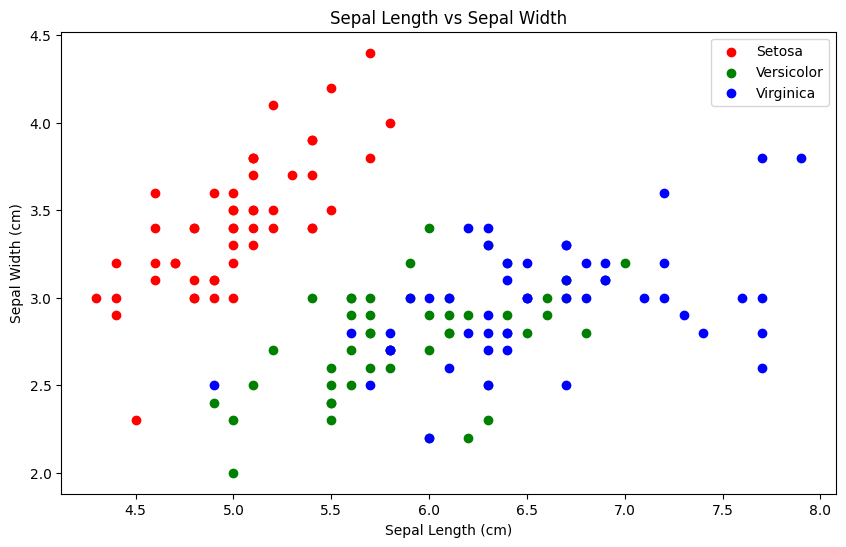

In [41]:
# Step 8 - Visualizing the results
species_names = ['Setosa', 'Versicolor', 'Virginica']

# Plot 1 - Sepal measurements
plt.figure(figsize=(10,6))
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(df[df['species'] == i]['sepal length (cm)'], df[df['species'] == i]['sepal width (cm)'], label=species_names[i], color=colors[i])
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.show()

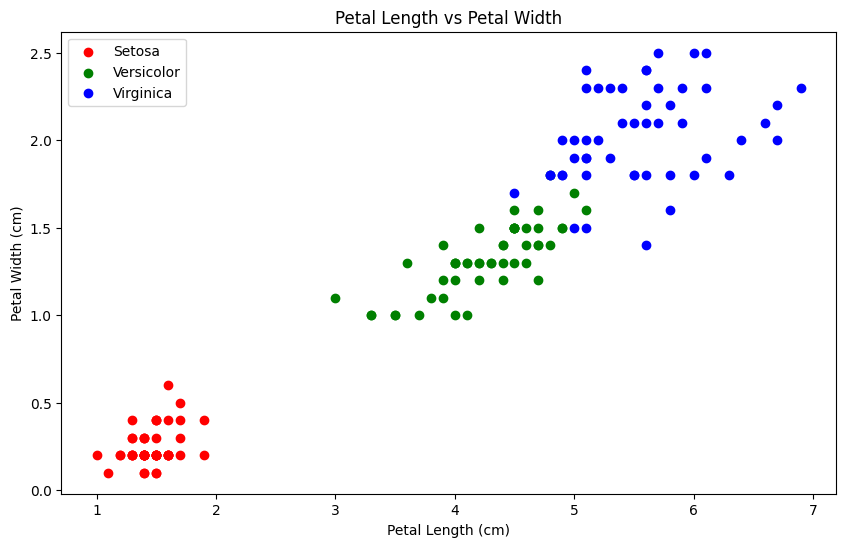

In [42]:
# Plot 2 - Petal measurements
plt.figure(figsize=(10,6))
for i in range(3):
    plt.scatter(df[df['species'] == i]['petal length (cm)'], df[df['species'] == i]['petal width (cm)'], label=species_names[i], color=colors[i])
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.show()

In [43]:
# Step 9 - Predicting from user input
print("\nEnter the iris flower MEASUREMENTS below:")
sepal_len = float(input("Enter the sepal length : "))
sepal_wid = float(input("Enter the sepal width  : "))
petal_len = float(input("Enter the petal length : "))
petal_wid = float(input("Enter the petal width  : "))
given_flower = [sepal_len, sepal_wid, petal_len, petal_wid]
prediction = knn.predict([given_flower])
print("\nGiven measurements :", given_flower)
print("🌸 Predicted Species:", species_names[prediction[0]])


Enter the iris flower MEASUREMENTS below:
Enter the sepal length : 6.3
Enter the sepal width  : 3.3
Enter the petal length : 2.2
Enter the petal width  : 0.2

Given measurements : [6.3, 3.3, 2.2, 0.2]
🌸 Predicted Species: Setosa
